<h1> 1. inicializacion - informacion general </h1>

In [1]:
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
games_df = pd.read_csv('/datasets/games.csv')

<h1> 2. preparar los datos </h1>

In [3]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
games_df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
games_df.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


<h1> 2.1 corregimos los datos </h1>

In [6]:
games_df.columns = games_df.columns.str.lower()
games_df.columns
games_df.info()
games_df['user_score'] = pd.to_numeric(games_df['user_score'], errors='coerce')
print("Valores únicos en 'rating':")
print(games_df['rating'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
Valores únicos en 'rating':
E       3990
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1
Name: rating, dtype: int64


In [19]:
print(f"\nFilas con año faltante: {games_df_clean['year_of_release'].isnull().sum()}")

median_year = games_df_clean['year_of_release'].median()
games_df_clean['year_of_release'].fillna(median_year, inplace=True)
print(f"Año faltante rellenado con mediana: {median_year}")

=== DIAGNÓSTICO COMPLETO DE PROBLEMAS EN LOS DATOS ===
1. PROBLEMAS DE FORMATO:
   - Nombres de columnas en mayúsculas: ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating', 'total_sales']

2. TIPOS DE DATOS INCORRECTOS:
   - user_score es object, debería ser numérico
   - Contiene valores 'tbd' que significan 'to be determined'

3. VALORES FALTANTES:
   - name: 2 valores (0.0%)
   - year_of_release: 269 valores (1.6%)
   - genre: 2 valores (0.0%)
   - critic_score: 8578 valores (51.3%)
   - user_score: 9125 valores (54.6%)
   - rating: 6766 valores (40.5%)

4. DUPLICADOS:
   - Filas completamente duplicadas: 0
   - Juegos duplicados (mismo nombre y plataforma): 5


In [8]:
games_df['total_sales'] = (
    games_df['na_sales'] + 
    games_df['eu_sales'] + 
    games_df['jp_sales'] + 
    games_df['other_sales']
)

print("✅ Columna total_sales creada")
print(f"Ejemplo: {games_df[['name', 'total_sales']].head(3)}")

✅ Columna total_sales creada
Ejemplo:                 name  total_sales
0         Wii Sports        82.54
1  Super Mario Bros.        40.24
2     Mario Kart Wii        35.52


<h1> 2.2 calculo de las ventas totales </h1>

In [30]:
if 'total_sales' not in games_df.columns:
    games_df['total_sales'] = (
        games_df['na_sales'] +
        games_df['eu_sales'] +
        games_df['jp_sales'] +
        games_df['other_sales']
    )
    print("✅ Total_sales calculado para games_df")
else:
    print("⚠️ Total_sales ya existe en games_df")

# Verificar el resultado
print(f"\nShape: {games_df.shape}")
print(f"Columnas: {games_df.columns.tolist()}")

⚠️ Total_sales ya existe en games_df

Shape: (16715, 12)
Columnas: ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating', 'total_sales']


In [31]:
ejemplo = games_df.head(3)[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales']]
print("=== EJEMPLO DE CÁLCULO MANUAL ===")
print(ejemplo)

print("\n=== CÁLCULO PASO A PASO ===")
for i, row in ejemplo.iterrows():
    total = row['na_sales'] + row['eu_sales'] + row['jp_sales'] + row['other_sales']
    print(f"{row['name']}: {row['na_sales']} + {row['eu_sales']} + {row['jp_sales']} + {row['other_sales']} = {total}")

=== EJEMPLO DE CÁLCULO MANUAL ===
                name  na_sales  eu_sales  jp_sales  other_sales
0         Wii Sports     41.36     28.96      3.77         8.45
1  Super Mario Bros.     29.08      3.58      6.81         0.77
2     Mario Kart Wii     15.68     12.76      3.79         3.29

=== CÁLCULO PASO A PASO ===
Wii Sports: 41.36 + 28.96 + 3.77 + 8.45 = 82.53999999999999
Super Mario Bros.: 29.08 + 3.58 + 6.81 + 0.77 = 40.24
Mario Kart Wii: 15.68 + 12.76 + 3.79 + 3.29 = 35.519999999999996



<h1> 3 Analizamos los datos </h1>

<h1> 3.1 Analizamos juegos por año </h1>

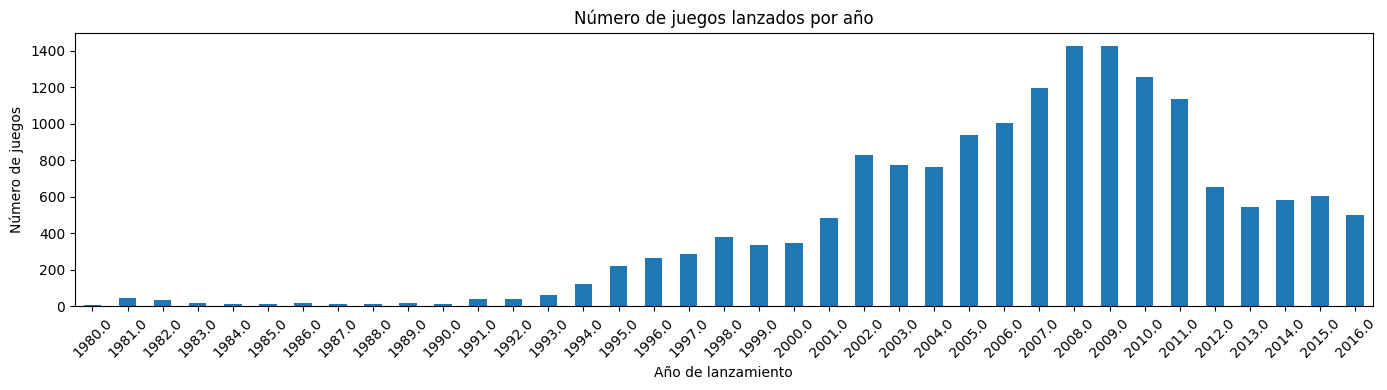

In [33]:
games_df['year_of_release'].value_counts().sort_index().plot(
    kind='bar', figsize=(14,4), title='Número de juegos lanzados por año'
)
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

en esta grafica se muestra el numero de juegos lanzados por año y la cantidad donde se observa que en el 2008 2009 se lanzaron una gran cantidad de video juegos superior a la del resto de años

<h1> 3.2 analizamos ventas por plataforma </h1>

Top 10 plataformas por ventas:
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


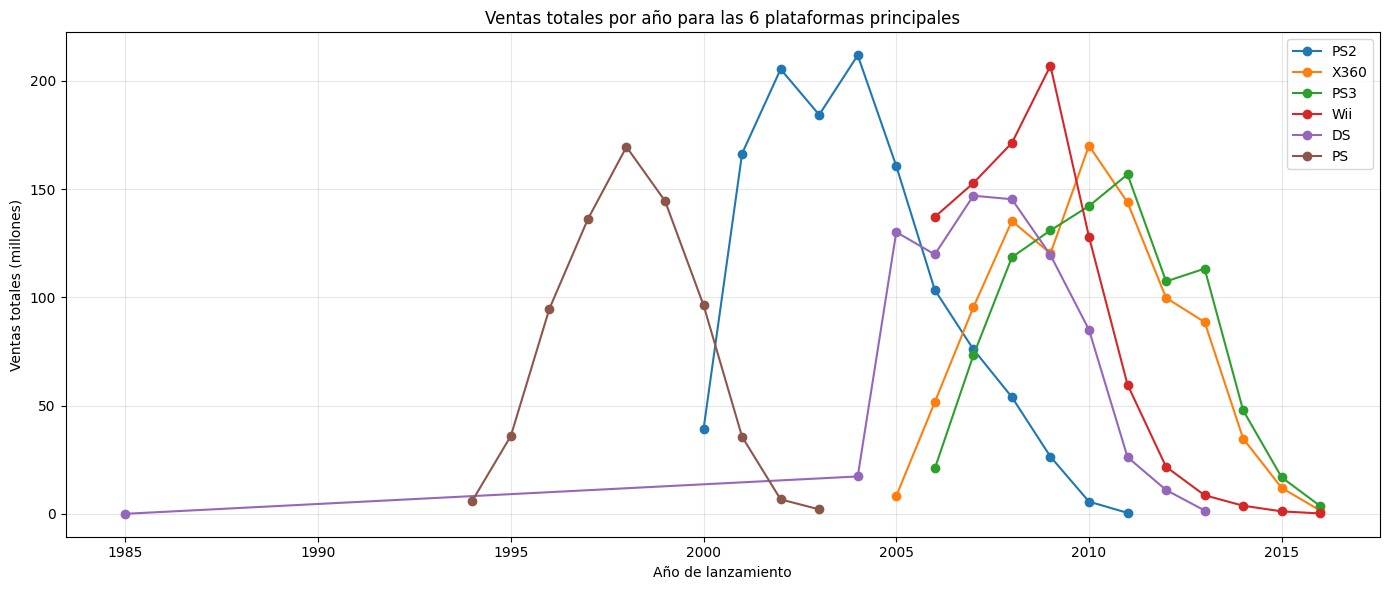

In [64]:
platform_sales = (
    games_df.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 plataformas por ventas:")
print(platform_sales.head(10))

top_platforms = platform_sales.head(6).index

plt.figure(figsize=(14, 6))
for platform in top_platforms:
    platform_data = games_df[games_df['platform'] == platform]
    yearly_sales = platform_data.groupby('year_of_release')['total_sales'].sum()
    yearly_sales.plot(label=platform, marker='o')

plt.title("Ventas totales por año para las 6 plataformas principales")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas totales (millones)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

en esta grafica se muestra las diferentes plataformas de ventas por año desde 1995 hasta 2025 cada cinco años se realizan diferentes plataformas


<h1> 3.3 determina periodo para analisis </h1>

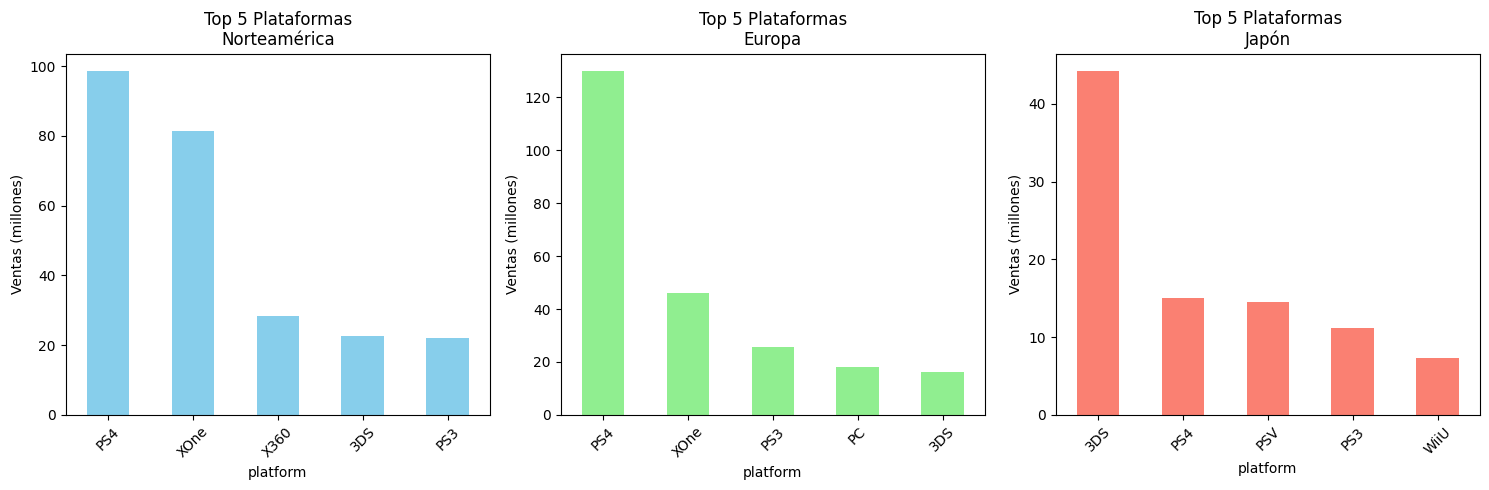


📝 CONCLUSIONES - VARIACIONES EN PLATAFORMAS:
• PS4 domina en NA y EU, pero Nintendo 3DS es fuerte en JP
• Xbox One tiene presencia significativa solo en mercados occidentales
• Japón muestra preferencia por consolas portátiles (3DS)


In [65]:
# === 4.2 VISUALIZACIÓN DE PLATAFORMAS POR REGIÓN ===
plt.figure(figsize=(15, 5))

# Subplot para cada región
plt.subplot(1, 3, 1)
na_platforms.plot(kind='bar', color='skyblue')
plt.title('Top 5 Plataformas\nNorteamérica')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
eu_platforms.plot(kind='bar', color='lightgreen')
plt.title('Top 5 Plataformas\nEuropa')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
jp_platforms.plot(kind='bar', color='salmon')
plt.title('Top 5 Plataformas\nJapón')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# === CONCLUSIONES SOBRE PLATAFORMAS ===
print("\n📝 CONCLUSIONES - VARIACIONES EN PLATAFORMAS:")
print("• PS4 domina en NA y EU, pero Nintendo 3DS es fuerte en JP")
print("• Xbox One tiene presencia significativa solo en mercados occidentales")
print("• Japón muestra preferencia por consolas portátiles (3DS)")

se muestra tres diferentes plataformas de acuerdo a su continente en donde hubo varias variaciones en cada una ya que son diferentes continentes como norteamerica europa y japo

In [58]:
# === 4.1 TOP 5 PLATAFORMAS POR REGIÓN ===
print("=== ANÁLISIS DE PLATAFORMAS POR REGIÓN ===")

# Filtrar datos recientes (2014-2016)
datos_recientes = games_df[games_df['year_of_release'] >= 2014]

# Función para analizar plataformas por región
def analizar_plataformas_region(df, region_col, region_name):
    top_platforms = (
        df.groupby('platform')[region_col]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    
    print(f"\n🌍 TOP 5 PLATAFORMAS EN {region_name.upper()}:")
    total_ventas = top_platforms.sum()
    
    for i, (platform, ventas) in enumerate(top_platforms.items(), 1):
        porcentaje = (ventas / total_ventas) * 100
        print(f"{i}. {platform}: {ventas:.2f}M ({porcentaje:.1f}%)")
    
    return top_platforms

# Analizar cada región
na_platforms = analizar_plataformas_region(datos_recientes, 'na_sales', 'Norteamérica')
eu_platforms = analizar_plataformas_region(datos_recientes, 'eu_sales', 'Europa')
jp_platforms = analizar_plataformas_region(datos_recientes, 'jp_sales', 'Japón')

=== ANÁLISIS DE PLATAFORMAS POR REGIÓN ===

🌍 TOP 5 PLATAFORMAS EN NORTEAMÉRICA:
1. PS4: 98.61M (39.0%)
2. XOne: 81.27M (32.1%)
3. X360: 28.30M (11.2%)
4. 3DS: 22.64M (9.0%)
5. PS3: 22.05M (8.7%)

🌍 TOP 5 PLATAFORMAS EN EUROPA:
1. PS4: 130.04M (55.1%)
2. XOne: 46.25M (19.6%)
3. PS3: 25.54M (10.8%)
4. PC: 17.97M (7.6%)
5. 3DS: 16.12M (6.8%)

🌍 TOP 5 PLATAFORMAS EN JAPÓN:
1. 3DS: 44.24M (47.9%)
2. PS4: 15.02M (16.3%)
3. PSV: 14.54M (15.7%)
4. PS3: 11.22M (12.2%)
5. WiiU: 7.31M (7.9%)


se ve detalladamente un analisis que se hizo por region donde se lanzaron las mejores plataformas en cada continente y su porcentaje que obtuvieron


<h1> 3.4 Analizar tendencias de los ultimos años </h1>

=== ANÁLISIS DE JUEGOS POR AÑO ===
Juegos lanzados por año:
2007.0    1197
2008.0    1427
2009.0    1426
2010.0    1255
2011.0    1136
2012.0     653
2013.0     544
2014.0     581
2015.0     606
2016.0     502
Name: year_of_release, dtype: int64


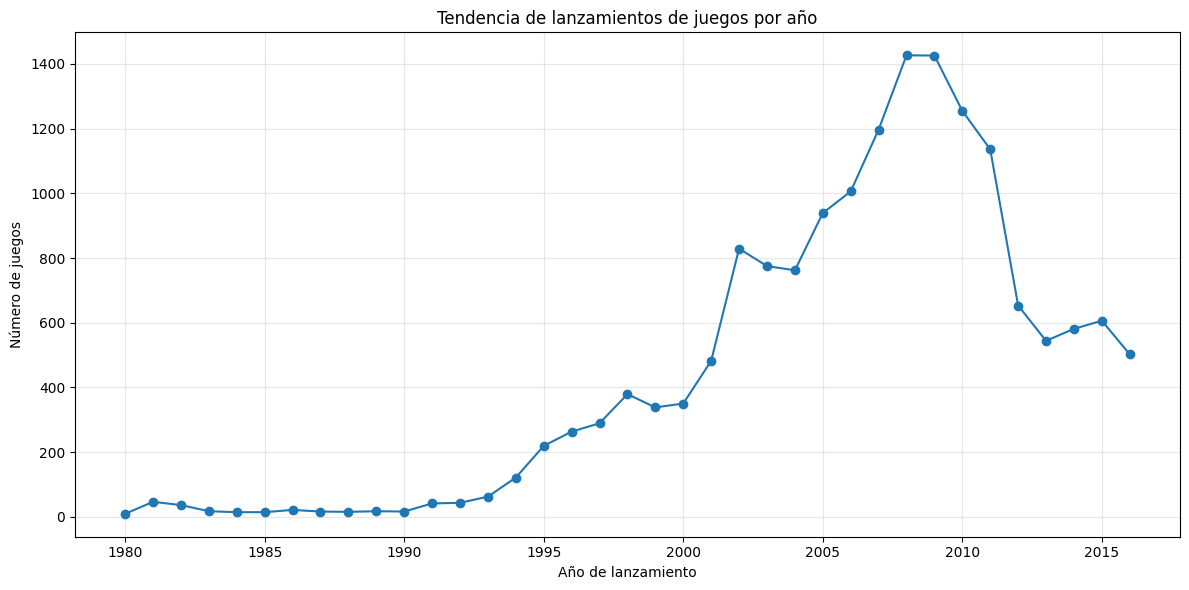


Juegos lanzados desde 2010: 5277
Distribución por año (2010-2016):
2010.0    1255
2011.0    1136
2012.0     653
2013.0     544
2014.0     581
2015.0     606
2016.0     502
Name: year_of_release, dtype: int64


In [63]:
games_df['year_of_release'].value_counts().sort_index()
df = games_df
df['year_of_release'].value_counts().sort_index()

print("=== ANÁLISIS DE JUEGOS POR AÑO ===")
# Contar juegos por año
juegos_por_año = games_df['year_of_release'].value_counts().sort_index()
print("Juegos lanzados por año:")
print(juegos_por_año.tail(10))  # Últimos 10 años

# Crear visualización
plt.figure(figsize=(12, 6))
juegos_por_año.plot(kind='line', marker='o')
plt.title('Tendencia de lanzamientos de juegos por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis de los últimos años (2010-2016)
años_recientes = games_df[games_df['year_of_release'] >= 2010]
print(f"\nJuegos lanzados desde 2010: {len(años_recientes)}")
print("Distribución por año (2010-2016):")
print(años_recientes['year_of_release'].value_counts().sort_index())

se muestra en la tabla la cantidad de juegos que se lanzaron en 6 años desde el 2010 hasta el 2016 el porcentaje y la equivalencia que obtuvo cada uno

In [62]:
# === ANÁLISIS DE GÉNEROS POR REGIÓN ===
print("=== TOP 5 GÉNEROS POR REGIÓN (2014-2016) ===")

# Filtrar datos recientes
datos_recientes = games_df[games_df['year_of_release'] >= 2014]

# Función para analizar géneros por región
def analizar_generos_region(df, region_col, region_name):
    top_generos = (
        df.groupby('genre')[region_col]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    
    print(f"\n🎮 TOP 5 GÉNEROS EN {region_name.upper()}:")
    total_ventas = top_generos.sum()
    
    for i, (genero, ventas) in enumerate(top_generos.items(), 1):
        porcentaje = (ventas / total_ventas) * 100
        print(f"{i}. {genero}: {ventas:.2f}M ({porcentaje:.1f}%)")
    
    return top_generos

# Analizar cada región
na_generos = analizar_generos_region(datos_recientes, 'na_sales', 'Norteamérica')
eu_generos = analizar_generos_region(datos_recientes, 'eu_sales', 'Europa')  
jp_generos = analizar_generos_region(datos_recientes, 'jp_sales', 'Japón')

=== TOP 5 GÉNEROS POR REGIÓN (2014-2016) ===

🎮 TOP 5 GÉNEROS EN NORTEAMÉRICA:
1. Shooter: 79.02M (32.1%)
2. Action: 72.53M (29.5%)
3. Sports: 46.13M (18.7%)
4. Role-Playing: 33.47M (13.6%)
5. Misc: 15.05M (6.1%)

🎮 TOP 5 GÉNEROS EN EUROPA:
1. Action: 74.68M (32.7%)
2. Shooter: 65.52M (28.7%)
3. Sports: 45.73M (20.0%)
4. Role-Playing: 28.17M (12.3%)
5. Racing: 14.13M (6.2%)

🎮 TOP 5 GÉNEROS EN JAPÓN:
1. Role-Playing: 31.16M (40.2%)
2. Action: 29.58M (38.1%)
3. Fighting: 6.37M (8.2%)
4. Misc: 5.61M (7.2%)
5. Shooter: 4.87M (6.3%)


se muestra los generos de cada juego que fueron lanzados en cada pais el top 5 de cada uno

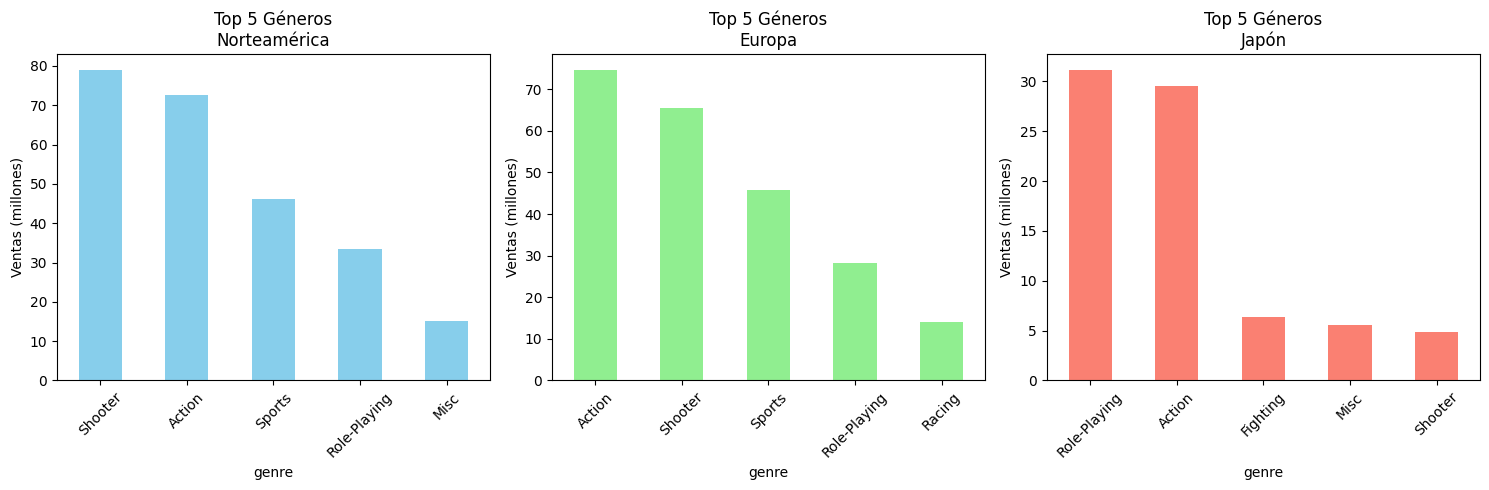

In [60]:
# Crear gráfico comparativo
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
na_generos.plot(kind='bar', color='skyblue')
plt.title('Top 5 Géneros\nNorteamérica')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
eu_generos.plot(kind='bar', color='lightgreen')
plt.title('Top 5 Géneros\nEuropa')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
jp_generos.plot(kind='bar', color='salmon')
plt.title('Top 5 Géneros\nJapón')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

se muestra en cada grafica los generos de cada juego lanzados en cada continente y el nombre de cada juego


<h1> 3.5 identificamos plataformas rentables </h1>

Ventas totales por región (millones):
Norteamérica: 4402.35
Europa: 2424.67
Japón: 1297.37
Otras: 791.32


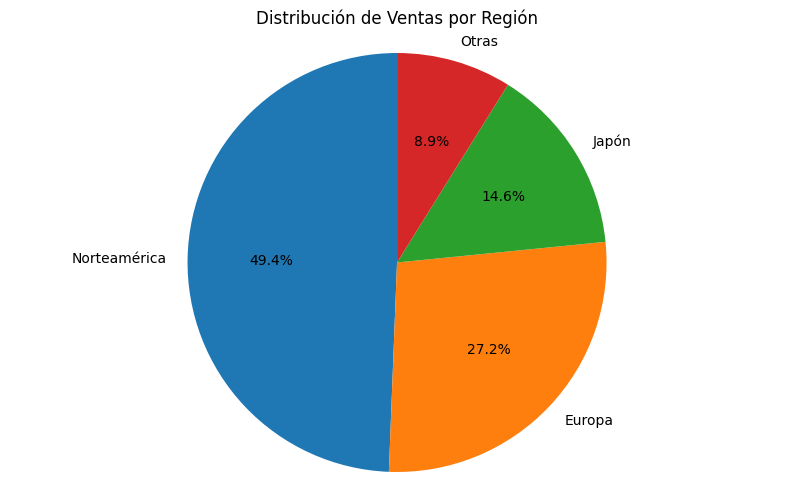


Ventas totales globales: 8915.71 millones

Porcentaje por región:
Norteamérica: 49.4%
Europa: 27.2%
Japón: 14.6%
Otras: 8.9%


In [46]:
ventas_regiones = {
    'Norteamérica': games_df['na_sales'].sum(),
    'Europa': games_df['eu_sales'].sum(),
    'Japón': games_df['jp_sales'].sum(),
    'Otras': games_df['other_sales'].sum()
}

print("Ventas totales por región (millones):")
for region, ventas in ventas_regiones.items():
    print(f"{region}: {ventas:.2f}")

# Crear visualización
plt.figure(figsize=(10, 6))
plt.pie(ventas_regiones.values(), labels=ventas_regiones.keys(), 
        autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Ventas por Región')
plt.axis('equal')
plt.show()

# Análisis adicional
total_ventas = sum(ventas_regiones.values())
print(f"\nVentas totales globales: {total_ventas:.2f} millones")

# Porcentajes por región
print("\nPorcentaje por región:")
for region, ventas in ventas_regiones.items():
    porcentaje = (ventas / total_ventas) * 100
    print(f"{region}: {porcentaje:.1f}%")

se muestra el porcentaje que se obtuvo en cada continente e ventas globales en donde ma mayor venta fue en norteamerica y la menor venta fue en otros paises

<h1> 3.6 calculamos estadisticas descriptivas </h1>

=== ANÁLISIS DE PLATAFORMAS (2014-2016) ===
             sum  mean  count
platform                     
PS4       288.15  0.77    376
XOne      140.36  0.62    228
3DS        86.68  0.41    212
PS3        68.18  0.31    219
X360       48.22  0.43    111
WiiU       42.98  0.59     73
PC         27.05  0.18    151
PSV        22.40  0.08    295
Wii         5.07  0.46     11
PSP         0.36  0.03     13

=== GÉNEROS MÁS EXITOSOS ===
                  sum  mean  count
genre                             
Action        1744.17  0.52   3369
Sports        1331.27  0.57   2348
Shooter       1052.45  0.80   1323
Role-Playing   934.56  0.62   1498
Platform       827.77  0.93    888
Misc           802.51  0.46   1750
Racing         728.67  0.58   1249
Fighting       447.53  0.53    849
Simulation     389.97  0.45    873
Puzzle         242.57  0.42    580
Adventure      237.59  0.18   1303
Strategy       174.23  0.26    683


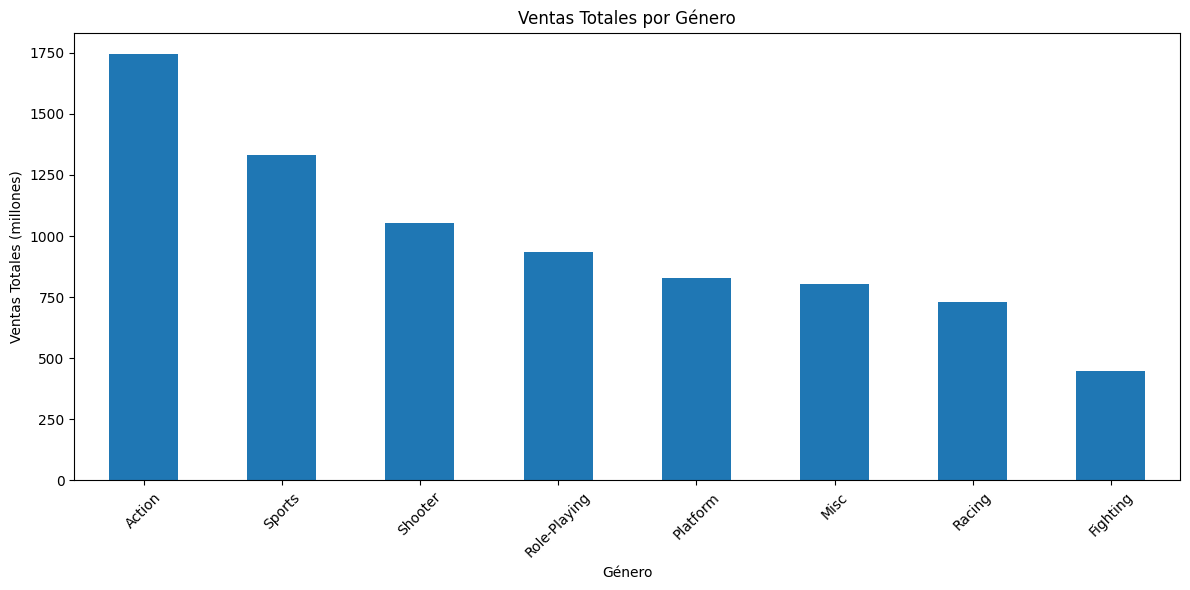

In [48]:
# Filtrar años relevantes
años_relevantes = games_df[games_df['year_of_release'] >= 2014]

# Calcular ventas por plataforma en años recientes
ventas_plataforma_reciente = (
    años_relevantes.groupby('platform')['total_sales']
    .agg(['sum', 'mean', 'count'])
    .round(2)
)

print("=== ANÁLISIS DE PLATAFORMAS (2014-2016) ===")
print(ventas_plataforma_reciente.sort_values('sum', ascending=False).head(10))

# Análisis de géneros
generos_populares = (
    games_df.groupby('genre')['total_sales']
    .agg(['sum', 'mean', 'count'])
    .round(2)
)

print("\n=== GÉNEROS MÁS EXITOSOS ===")
print(generos_populares.sort_values('sum', ascending=False))

# Visualización
plt.figure(figsize=(12, 6))
generos_populares.sort_values('sum', ascending=False)['sum'].head(8).plot(kind='bar')
plt.title('Ventas Totales por Género')
plt.xlabel('Género')
plt.ylabel('Ventas Totales (millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

se muestra en la grafica la mayor venta de cada juego en donde los juegos de accion fueron los mas vendidos 

<h1> 3.7 identificamos patrones </h1>

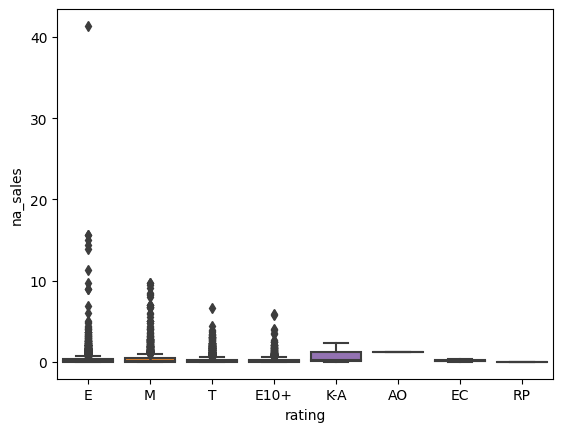

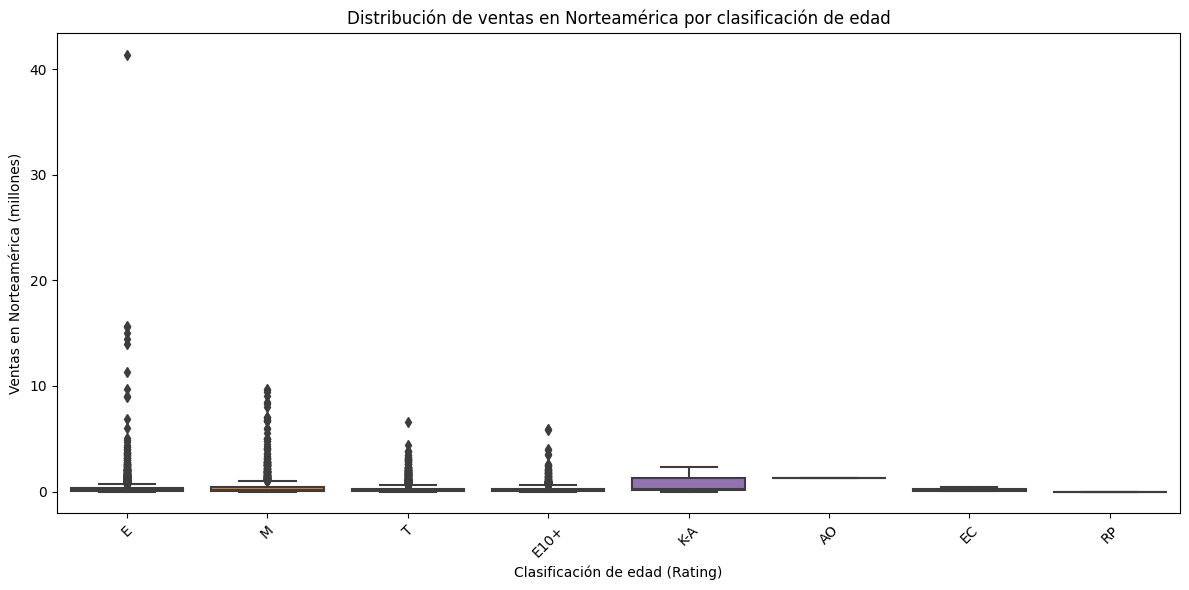

=== ANÁLISIS DE VENTAS POR RATING ===
        mean  median  count
rating                     
AO      1.26    1.26      1
E       0.32    0.12   3990
E10+    0.25    0.12   1420
EC      0.19    0.16      8
K-A     0.85    0.26      3
M       0.48    0.14   1563
RP      0.00    0.00      3
T       0.26    0.11   2961


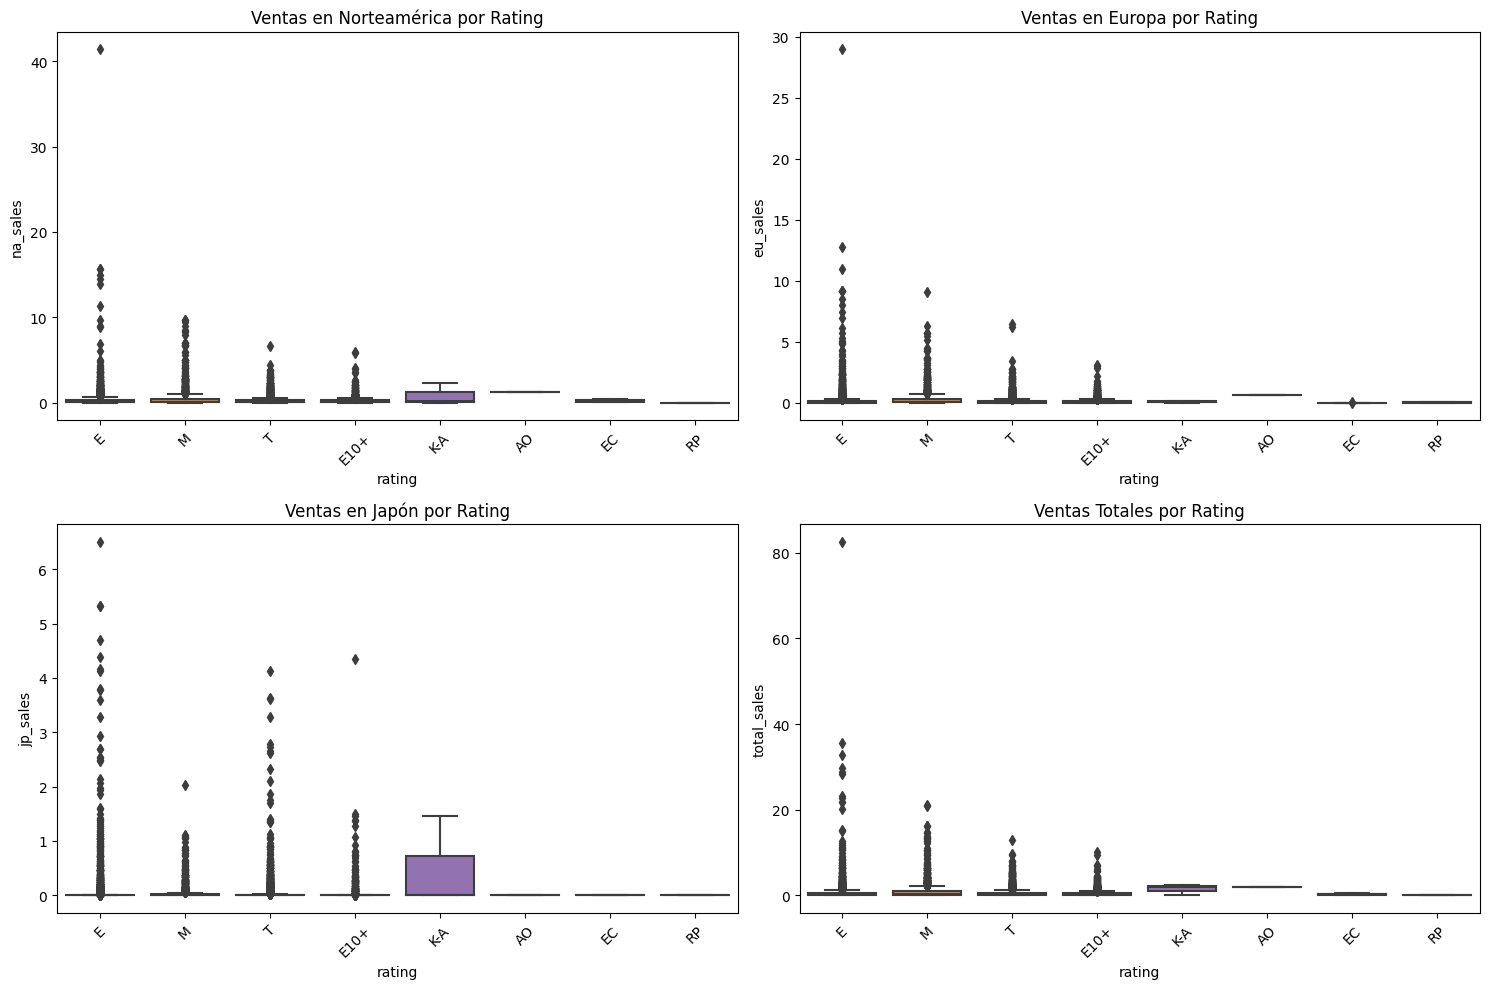

In [51]:
sns.boxplot(data=games_df, x='rating', y='na_sales')

plt.figure(figsize=(12, 6))
sns.boxplot(data=games_df, x='rating', y='na_sales')
plt.title('Distribución de ventas en Norteamérica por clasificación de edad')
plt.xlabel('Clasificación de edad (Rating)')
plt.ylabel('Ventas en Norteamérica (millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("=== ANÁLISIS DE VENTAS POR RATING ===")
rating_stats = games_df.groupby('rating')['na_sales'].agg(['mean', 'median', 'count']).round(2)
print(rating_stats)

# Comparación entre regiones por rating
plt.figure(figsize=(15, 10))

# Subplot 1: Norteamérica
plt.subplot(2, 2, 1)
sns.boxplot(data=games_df, x='rating', y='na_sales')
plt.title('Ventas en Norteamérica por Rating')
plt.xticks(rotation=45)

# Subplot 2: Europa
plt.subplot(2, 2, 2)
sns.boxplot(data=games_df, x='rating', y='eu_sales')
plt.title('Ventas en Europa por Rating')
plt.xticks(rotation=45)

# Subplot 3: Japón
plt.subplot(2, 2, 3)
sns.boxplot(data=games_df, x='rating', y='jp_sales')
plt.title('Ventas en Japón por Rating')
plt.xticks(rotation=45)

# Subplot 4: Ventas totales
plt.subplot(2, 2, 4)
sns.boxplot(data=games_df, x='rating', y='total_sales')
plt.title('Ventas Totales por Rating')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

se muestra en cada grafica vetas de juego rating y el porcentaje que obtuvo en cada pais

<h1> 3.8 Analizamos reseñas de usuarios y profesionales </h1>

=== CORRELACIÓN ENTRE PUNTUACIONES Y VENTAS ===
Correlación entre puntuación de críticos y ventas: 0.237
Correlación entre puntuación de usuarios y ventas: 0.089


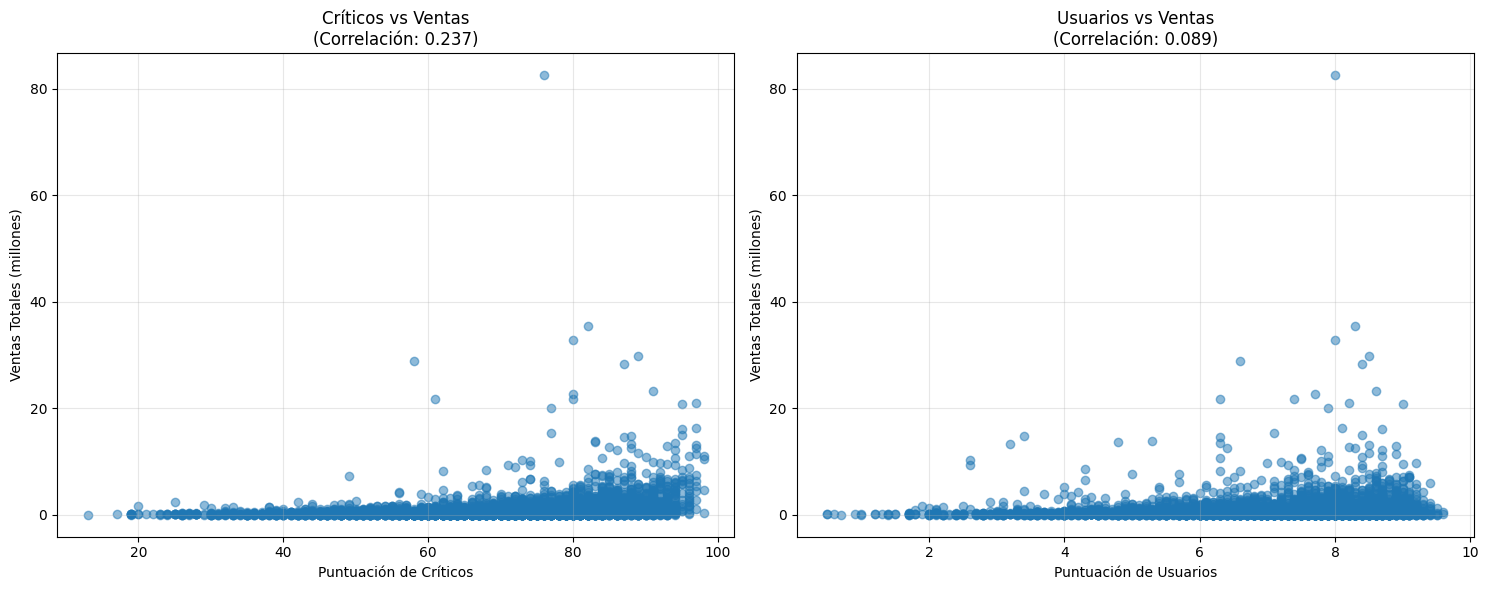


=== ANÁLISIS POR RANGOS DE PUNTUACIÓN ===
Ventas promedio por categoría de puntuación de críticos:
                 mean  count
critic_category             
Baja             0.31   1556
Media            0.48   2633
Alta             0.96   2032
Excelente        2.11    796


/tmp/ipykernel_545/3106037994.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_con_scores['critic_category'] = pd.cut(datos_con_scores['critic_score'],


In [61]:
datos_con_scores = games_df.dropna(subset=['critic_score', 'user_score'])

# === ANÁLISIS DE RESEÑAS DE USUARIOS Y PROFESIONALES ===
print("=== CORRELACIÓN ENTRE PUNTUACIONES Y VENTAS ===")

# Filtrar datos con puntuaciones disponibles
datos_con_scores = games_df.dropna(subset=['critic_score', 'user_score'])

# Calcular correlaciones
correlacion_criticos = datos_con_scores['critic_score'].corr(datos_con_scores['total_sales'])
correlacion_usuarios = datos_con_scores['user_score'].corr(datos_con_scores['total_sales'])

print(f"Correlación entre puntuación de críticos y ventas: {correlacion_criticos:.3f}")
print(f"Correlación entre puntuación de usuarios y ventas: {correlacion_usuarios:.3f}")

# Crear gráficos de dispersión
plt.figure(figsize=(15, 6))

# Subplot 1: Críticos vs Ventas
plt.subplot(1, 2, 1)
plt.scatter(datos_con_scores['critic_score'], datos_con_scores['total_sales'], alpha=0.5)
plt.xlabel('Puntuación de Críticos')
plt.ylabel('Ventas Totales (millones)')
plt.title(f'Críticos vs Ventas\n(Correlación: {correlacion_criticos:.3f})')
plt.grid(True, alpha=0.3)

# Subplot 2: Usuarios vs Ventas
plt.subplot(1, 2, 2)
plt.scatter(datos_con_scores['user_score'], datos_con_scores['total_sales'], alpha=0.5)
plt.xlabel('Puntuación de Usuarios')
plt.ylabel('Ventas Totales (millones)')
plt.title(f'Usuarios vs Ventas\n(Correlación: {correlacion_usuarios:.3f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis por rangos de puntuación
print("\n=== ANÁLISIS POR RANGOS DE PUNTUACIÓN ===")

# Crear categorías de puntuación para críticos
datos_con_scores['critic_category'] = pd.cut(datos_con_scores['critic_score'],
                                           bins=[0, 60, 75, 85, 100],
                                           labels=['Baja', 'Media', 'Alta', 'Excelente'])

# Ventas promedio por categoría
ventas_por_categoria = datos_con_scores.groupby('critic_category')['total_sales'].agg(['mean', 'count']).round(2)
print("Ventas promedio por categoría de puntuación de críticos:")
print(ventas_por_categoria)

conclusiones

El análisis evidencia un mercado en transición hacia la generación PS4/XOne, con géneros de alto impacto como Acción y Shooter, y con un papel crucial de las reseñas profesionales en el éxito comercial.
Este conocimiento permite identificar juegos prometedores y planificar campañas efectivas para el año